Connecting to python jupter kernel

```markdown
cd ..
.\py313\Scripts\activate
cd .\2D_optical_vision_mapping\
jupyter notebook
```


In [1]:
import pandas as pd
import numpy as np

## 1. Plot the glass scale dot location with respect to the encoder position

In [2]:
first_run_log_file_path = r"C:\Users\malit\Documents\GitHub\2026_01_08_17_00_29\Log_file_1D_expansion.csv"
# read csv file
first_run_log_df = pd.read_csv(first_run_log_file_path)

# convert to numpy array
first_run_log_np = first_run_log_df.to_numpy()

In [3]:
second_run_log_file_path = r"C:\Users\malit\Documents\GitHub\2026_01_08_17_09_29\Log_file_1D_expansion.csv"

# read csv file
second_run_log_df = pd.read_csv(second_run_log_file_path)

# print header
print(second_run_log_df.head())

# convert to numpy array
second_run_log_np = second_run_log_df.to_numpy()


                  Time  Run image name  Y position  X position  \
0  2026-01-08-17-09-34    0      0.png           0           0   
1  2026-01-08-17-09-45    0      1.png           1           0   
2  2026-01-08-17-09-55    0      2.png           2           0   
3  2026-01-08-17-10-06    0      3.png           3           0   
4  2026-01-08-17-10-16    0      4.png           4           0   

   Y comand position  X comand position  Z comand position  \
0         266.069246         125.925377              24.31   
1         266.069688         130.924860              24.31   
2         266.070013         135.924751              24.31   
3         266.070218         140.924742              24.31   
4         266.070633         145.924398              24.31   

   axis_x_position_error  axis_y_position_error  axis_z_position_error  \
0               0.000015               -0.00000                      0   
1               0.000005                0.00002                      0   
2       

## 1. Plot the temperature vs time 

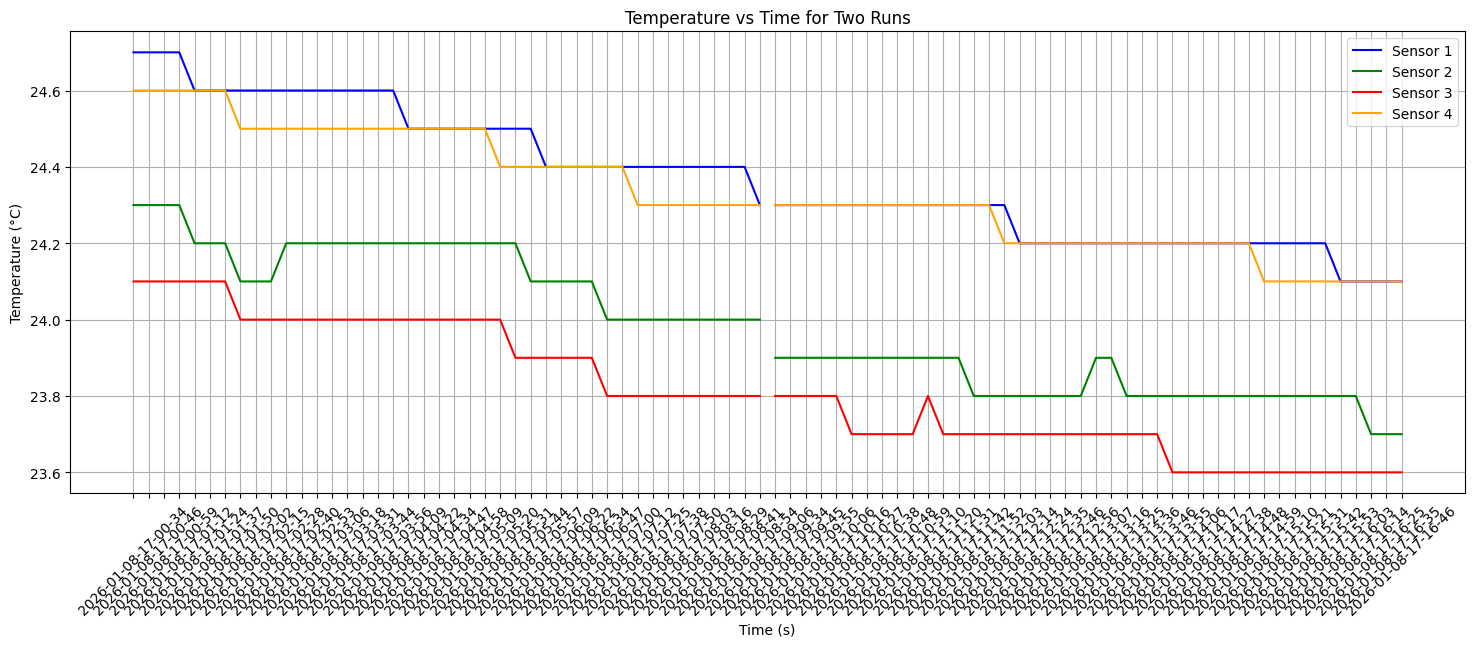

In [15]:
# time stamp is in column 0
# temperature is in column 14,15,16,17
first_run_time = first_run_log_np[:, 0]
first_run_temp = first_run_log_np[:, 14:18]

second_run_time = second_run_log_np[:, 0]
second_run_temp = second_run_log_np[:, 14:18]
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 6))
# use same color for same sensor in both runs
colors = ['blue', 'green', 'red', 'orange']
for i in range(4):
    plt.plot(first_run_time, first_run_temp[:, i], color=colors[i], label=f'Sensor {i+1}')
    plt.plot(second_run_time, second_run_temp[:, i], color=colors[i])
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature vs Time for Two Runs')
# roteate x ticks by 45 degrees
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

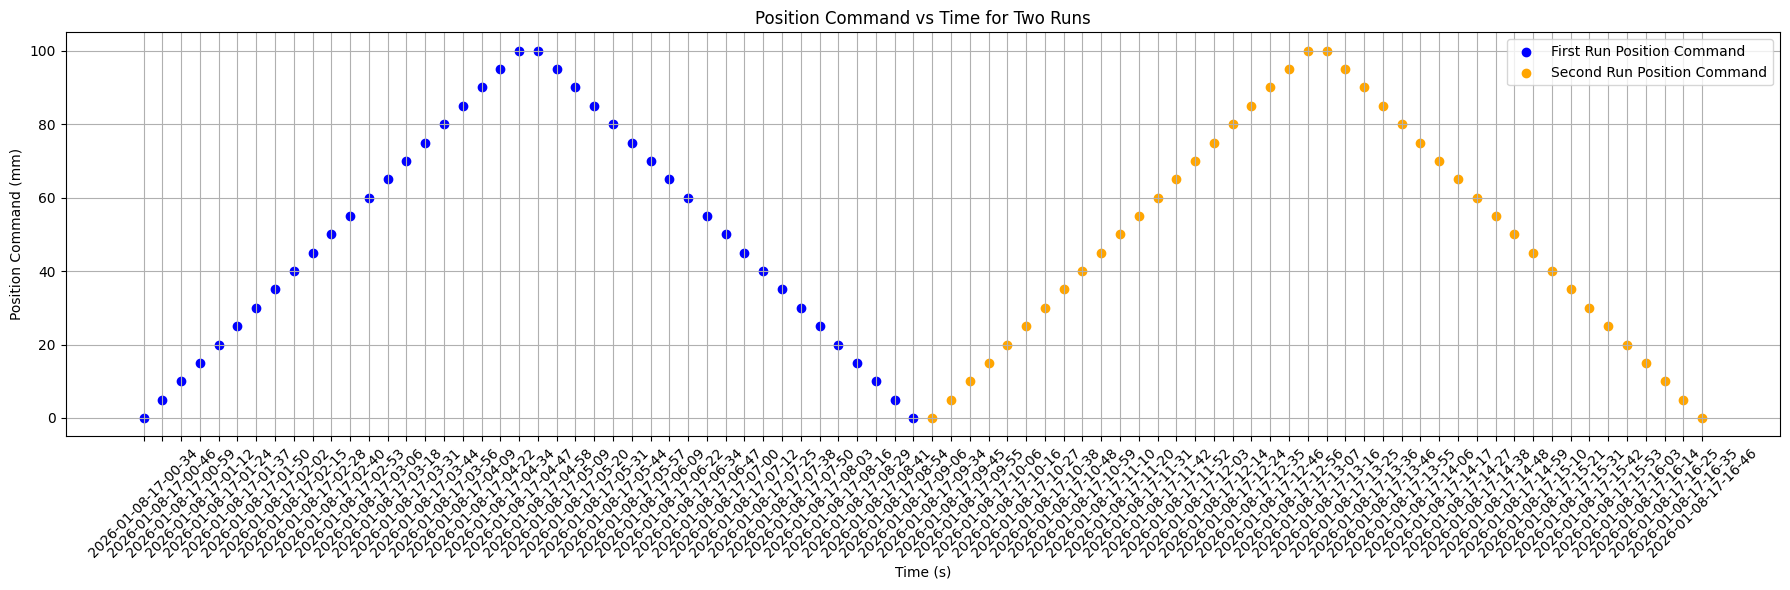

In [16]:
# plot position command vs time for both runs
import matplotlib.pyplot as plt
# plot dimentions
plt.figure(figsize=(18, 6))
# lable indivitlal point value near the point in the plot 


plt.scatter(first_run_time, first_run_log_np[:, 6]-first_run_log_np[0,6], label='First Run Position Command', color='blue')
plt.scatter(second_run_time, second_run_log_np[:, 6]-first_run_log_np[0,6], label='Second Run Position Command', color='orange')
plt.xlabel('Time (s)')
plt.ylabel('Position Command (mm)')
plt.title('Position Command vs Time for Two Runs')
# roteate x ticks by 45 degrees
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [60]:
first_run_log_np[0,6]
step_distance = 99.9885/20  # mm

print("Initial Position (mm):", first_run_log_np[0,6])
print("Step distance (mm):", step_distance)

commanded_positions_first = [i * step_distance for i in range(0, 21,1)]
# print only six decimal places
commanded_positions_first = [round(pos, 6) for pos in commanded_positions_first]
print("Commanded Positions First Run (mm):", commanded_positions_first)

# add another 20 steps staring with last of commanded_positions_first then dicrese by step_distance
commanded_positions_second = [commanded_positions_first[-1] - i * step_distance for i in range(1, 21,1)]
commanded_positions_second = [round(pos, 6) for pos in commanded_positions_second]
print("Commanded Positions Second Run (mm):", commanded_positions_second)


commanded_positions = [0.0, 4.999425, 9.99885, 14.998275, 19.9977, 24.997125, 29.99655, 34.995975, 39.9954, 44.994825, 49.99425, 54.993675, 59.9931, 64.992525, 69.99195, 74.991375, 79.9908, 84.990225, 89.98965, 94.989075, 99.9885, 99.9885, 94.989075, 89.98965, 84.990225, 79.9908, 74.991375, 69.99195, 64.992525, 59.9931, 54.993675, 49.99425, 44.994825, 39.9954, 34.995975, 29.99655, 24.997125, 19.9977, 14.998275, 9.99885, 4.999425, 0.0]
print("Commanded Positions Combined (mm):", commanded_positions)
print("Length of Commanded Positions Combined:", len(commanded_positions))

Initial Position (mm): 125.925429
Step distance (mm): 4.9994250000000005
Commanded Positions First Run (mm): [0.0, 4.999425, 9.99885, 14.998275, 19.9977, 24.997125, 29.99655, 34.995975, 39.9954, 44.994825, 49.99425, 54.993675, 59.9931, 64.992525, 69.99195, 74.991375, 79.9908, 84.990225, 89.98965, 94.989075, 99.9885]
Commanded Positions Second Run (mm): [94.989075, 89.98965, 84.990225, 79.9908, 74.991375, 69.99195, 64.992525, 59.9931, 54.993675, 49.99425, 44.994825, 39.9954, 34.995975, 29.99655, 24.997125, 19.9977, 14.998275, 9.99885, 4.999425, -0.0]
Commanded Positions Combined (mm): [0.0, 4.999425, 9.99885, 14.998275, 19.9977, 24.997125, 29.99655, 34.995975, 39.9954, 44.994825, 49.99425, 54.993675, 59.9931, 64.992525, 69.99195, 74.991375, 79.9908, 84.990225, 89.98965, 94.989075, 99.9885, 99.9885, 94.989075, 89.98965, 84.990225, 79.9908, 74.991375, 69.99195, 64.992525, 59.9931, 54.993675, 49.99425, 44.994825, 39.9954, 34.995975, 29.99655, 24.997125, 19.9977, 14.998275, 9.99885, 4.99942

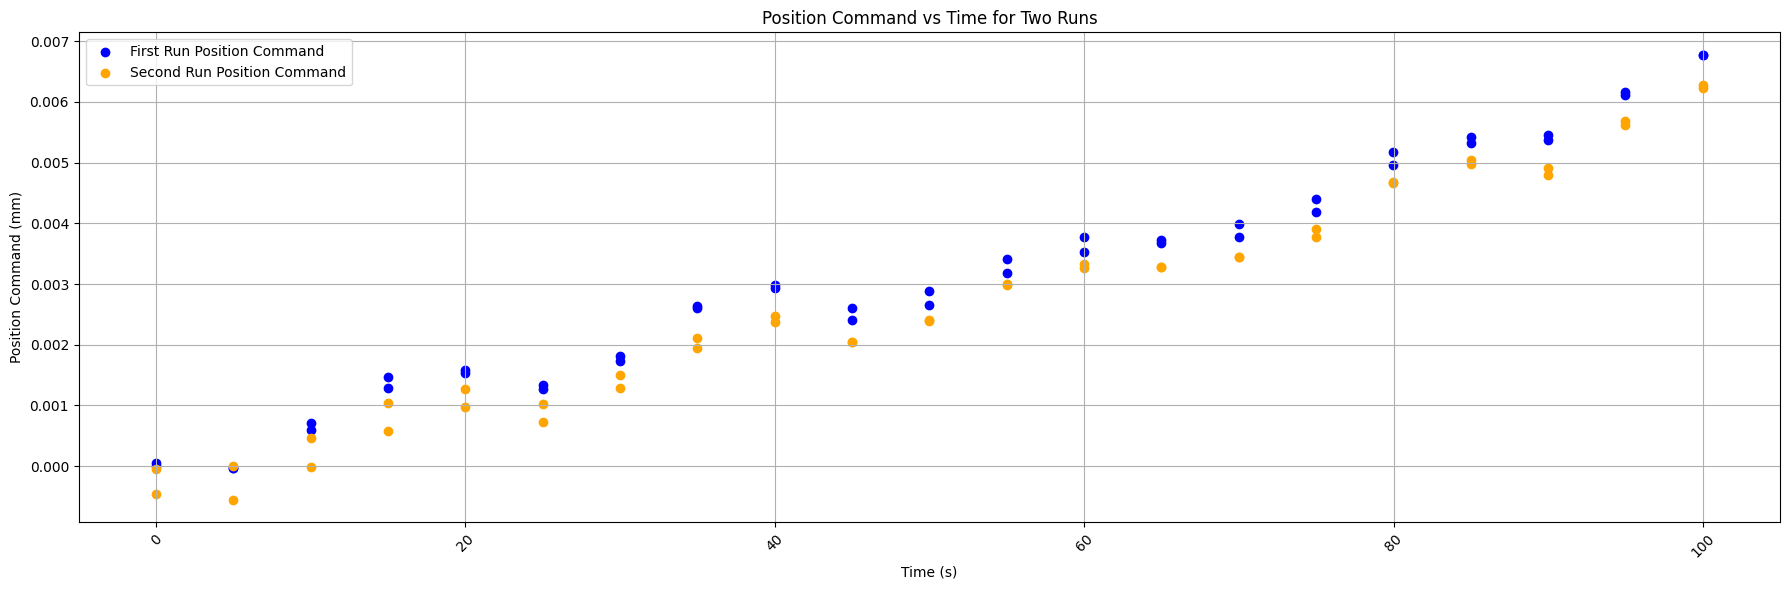

In [ ]:
# plot position command vs time for both runs
import matplotlib.pyplot as plt
# plot dimentions
plt.figure(figsize=(18, 6))
# lable indivitlal point value near the point in the plot 


plt.scatter(commanded_positions[0:42], first_run_log_np[0:42, 6]-first_run_log_np[0,6] - commanded_positions[0:42], label='First Run Position Command', color='blue')
plt.scatter(commanded_positions[0:42], second_run_log_np[0:42, 6]-first_run_log_np[0,6] - commanded_positions[0:42], label='Second Run Position Command', color='orange')

plt.xlabel('Time (s)')
plt.ylabel('Position Command (mm)')
plt.title('Position Command vs Time for Two Runs')
# roteate x ticks by 45 degrees
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()